In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


In [2]:
df=pd.read_csv('/content/drive/MyDrive/KC House Dataset.zip')

# Problem Statement

Goal: Predict house prices using features like area, location, and condition.

Type: Supervised Learning (Regression)

Target Variable: price

# DATA DESCRIPTION

In [3]:
df['bathrooms'].unique()

array([1.  , 2.25, 3.  , 2.  , 4.5 , 1.5 , 2.5 , 1.75, 2.75, 3.25, 4.  ,
       3.5 , 0.75, 4.75, 5.  , 4.25, 3.75, 0.  , 1.25, 5.25, 6.  , 0.5 ,
       5.5 , 6.75, 5.75, 8.  , 7.5 , 7.75, 6.25, 6.5 ])

In [4]:
df.shape

(21613, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [6]:
df.isnull().mean()

,0
id,0.0
date,0.0
price,0.0
bedrooms,0.0
bathrooms,0.0
sqft_living,0.0
sqft_lot,0.0
floors,0.0
waterfront,0.0
view,0.0


In [7]:
# Date itself has no meaning unless converted into year
df['sale_year'] = pd.to_datetime(df['date']).dt.year
df.drop(['date'], axis=1, inplace=True)


In [8]:
# Create House Age feature
df['Age'] = 2026 - df['yr_built']
df.drop(['yr_built'],axis=1,inplace=True)

In [9]:
df.corr()['price'].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


<Axes: xlabel='price', ylabel='Density'>

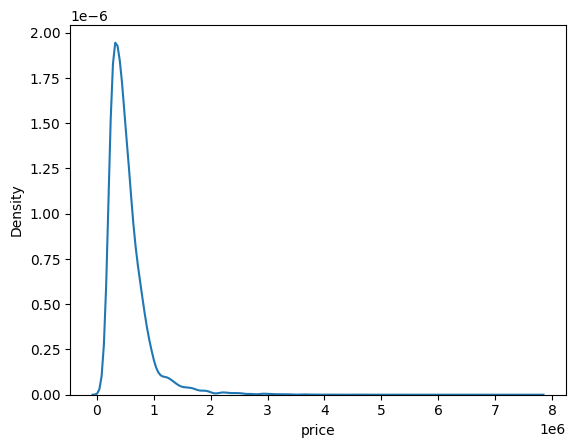

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['price'])

House prices are heavily right-skewed, with most homes clustered around 200,000–600,000 and a few multi-million properties forming extreme outliers on the right.

# Feature Engineering

In [11]:
# To represent the total usable house area, which helps the model make better predictions.
df['Total_House_Area'] = df['sqft_living'] + df['sqft_basement']
df.drop(['sqft_living','sqft_basement'],axis=1,inplace=True)




# We did this to convert zipcode into a meaningful numeric feature (average price) so the model can understand location impact on price.
zipcode_mean = df.groupby('zipcode')['price'].mean()
df['zipcode_target'] = df['zipcode'].map(zipcode_mean)
# We drop zipcode because its information is already captured in zipcode_target, making the original column redundant and unnecessary for the model.
df.drop('zipcode', axis=1, inplace=True)


# Convert yr_renovated into a binary renovated flag and drop the original column
df['renovated']=[0 if x==0 else 1 for x in df['yr_renovated']]
df.drop('yr_renovated',axis=1,inplace=True)




#I removed sqft_living15 and sqft_lot15 because they are highly correlated with sqft_living and sqft_lot.
df.drop(['sqft_living15', 'sqft_lot15'], axis=1, inplace=True)





# EDA

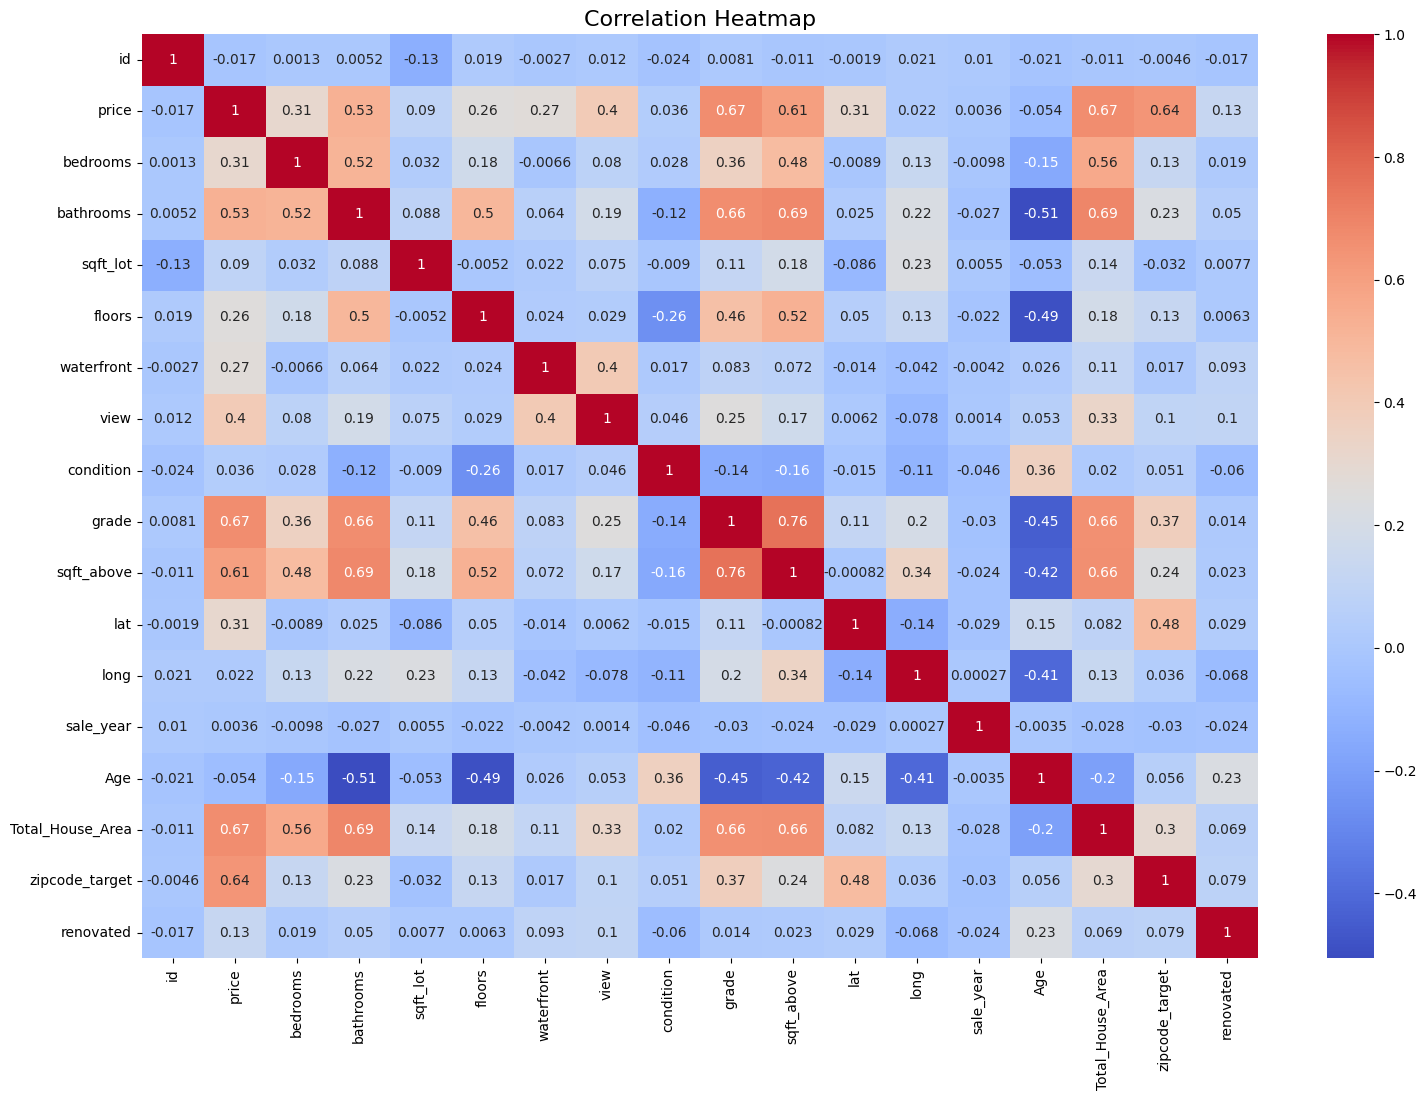

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))   # Width = 18, Height = 12
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


/tmp/ipykernel_1855/2134387191.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['bedrooms'],y=df['price'],palette='Set2')


Text(0.5, 1.0, 'Bedrooms by Price')

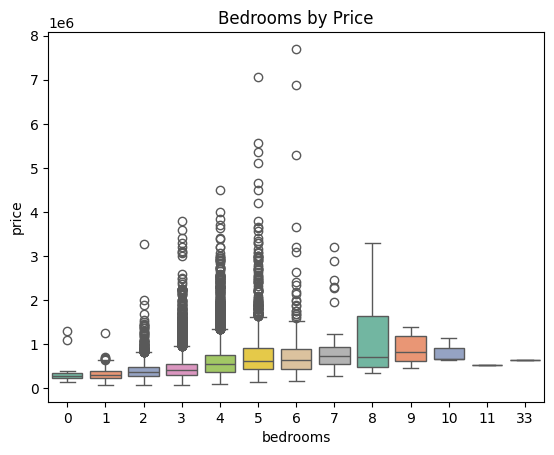

In [13]:
sns.boxplot(x=df['bedrooms'],y=df['price'],palette='Set2')
plt.title('Bedrooms by Price')

The boxplot shows that house prices generally increase as the number of bedrooms increases.

Most houses are in the 3–6 bedroom range, and these categories have many high-price outliers.

Price variation is large within each bedroom group, especially for 4 and 5 bedrooms.


Text(0.5, 1.0, 'bathrooms by price')

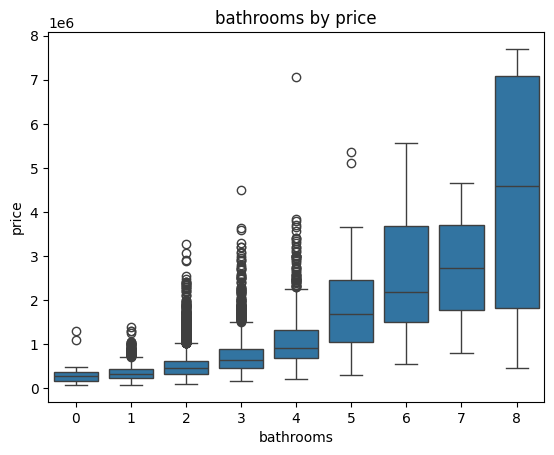

In [14]:

df['bathrooms'] = df['bathrooms'].round().astype(int)
sns.boxplot(x=df['bathrooms'],y=df['price'])
plt.title('bathrooms by price')


Number of bathrooms increases,price is increases showing a clear positive relationship.

Homes with more bathrooms tend to be larger and more luxurious, so they usually cost more.

A few high-price outliers appear for houses with many bathrooms, indicating premium properties.

/tmp/ipykernel_1855/2693506667.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='waterfront', y='price', data=df,palette='Set2')


Text(0.5, 1.0, 'waterfront by price')

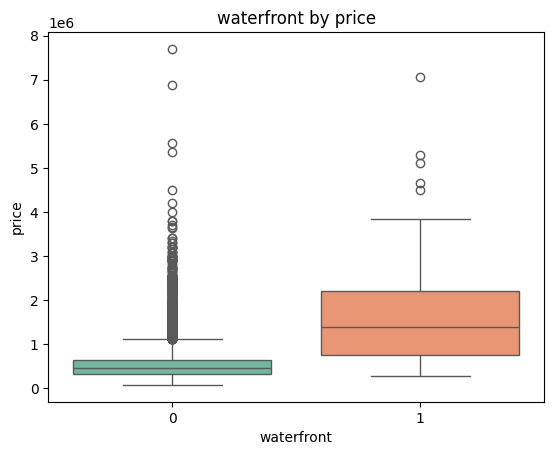

In [15]:
sns.boxplot(x='waterfront', y='price', data=df,palette='Set2')
plt.title('waterfront by price')


The median price for waterfront homes is much higher.
Waterfront properties also show greater price variation.
Overall, having a waterfront strongly increases house price.

/tmp/ipykernel_1855/1287975989.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='view', y='price', data=df,palette='Set2')


Text(0.5, 1.0, 'view by price')

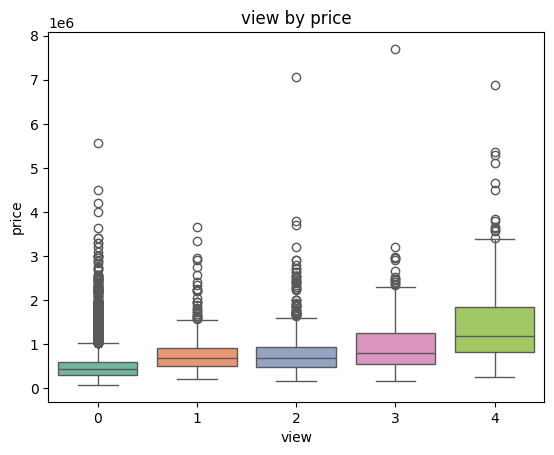

In [16]:
sns.boxplot(x='view', y='price', data=df,palette='Set2')
plt.title('view by price')



The boxplot shows that house prices increase as the view rating increases (from 0 to 4).

Houses with a better view (3 and 4) have much higher median prices.

There are many high-price outliers, especially in higher view categories.
Overall, a better view positively impacts house price.

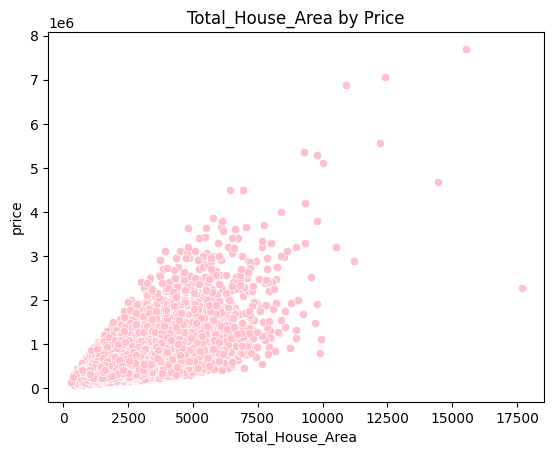

In [17]:
sns.scatterplot(x=df['Total_House_Area'],
                y=df['price'],
                color='pink')

plt.title('Total_House_Area by Price')
plt.show()


The scatter plot shows a strong positive relationship between living area (sqft_living) and house price.

As square footage increases, the price also increases significantly.

Higher-priced houses mostly have larger living areas.

Overall, sqft_living is strongly correlated with price.

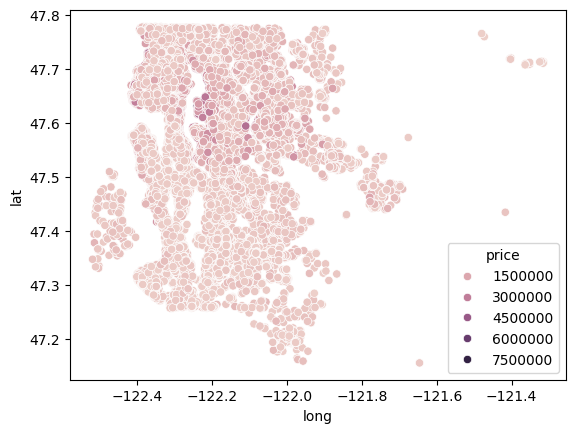

In [18]:
sns.scatterplot(x='long', y='lat',hue='price',data=df)
plt.show()


Each dot represents a house location (longitude & latitude).

Most houses are light pink → meaning prices are around 1.5M or lower.

Dark purple dots (4M–7.5M) are fewer and concentrated in specific areas.

Higher-priced houses appear clustered around central/northern areas (around lat 47.6–47.7).

/tmp/ipykernel_1855/2736964193.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='price', data=df,palette='Set2')


Text(0.5, 1.0, 'Condition by price')

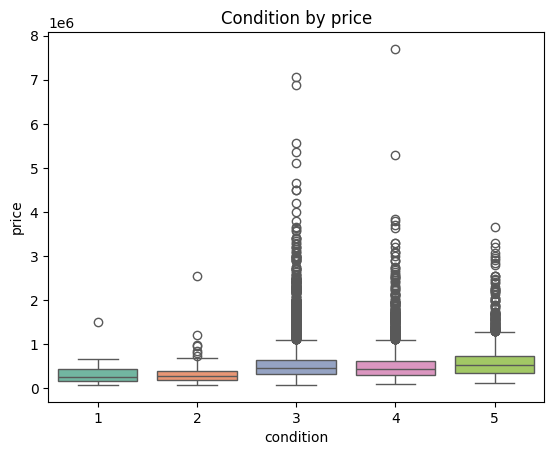

In [19]:
sns.boxplot(x='condition', y='price', data=df,palette='Set2')
plt.title('Condition by price')

The boxplot shows that house prices slightly increase as the condition rating increases from 1 to 5.

Homes with better condition generally have higher median prices.

However, price variation and outliers exist in all condition categories.

Text(0.5, 1.0, 'sqft_lot by price')

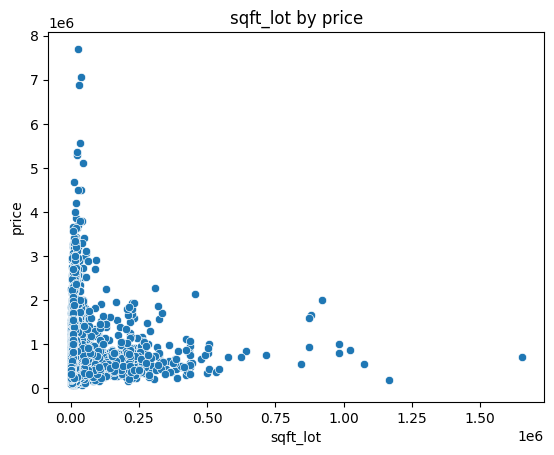

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='sqft_lot', y='price', data=df)
plt.title('sqft_lot by price')

As sqft_lot increases, price does not increase strongly — the relationship looks weak.

/tmp/ipykernel_1855/2844912070.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['renovated'],y=df['price'],palette='Set2')


Text(0.5, 1.0, 'renovated by price')

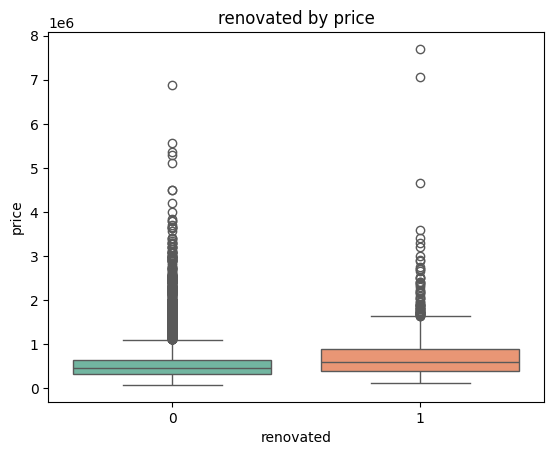

In [21]:
sns.boxplot(x=df['renovated'],y=df['price'],palette='Set2')
plt.title('renovated by price')


Houses with renovation (1) have a higher median price compared to non-renovated (0).

 The price range for renovated houses is generally higher.

# Data preprocessing

In [22]:
# These features have negative correlation:
df.drop(['id','Age'],axis=1,inplace=True)

# Slicing
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=123)



#  Model Selection


# 1.Linear Regression
“Used to predict continuous values when there is a linear relationship between features and target.”


# 2.Random Forest
Used to handle complex and non-linear relationships by combining multiple decision trees for better accuracy

# 3.XGBRegressor
Used to achieve high accuracy by combining gradient boosting with optimized performance, effectively handling complex and non-linear relationships.




In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)



print("Test MAE:", test_mae)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2 (%):", test_r2 * 100)





Test MAE: 100983.26242504107
Train RMSE: 170146.0317121328
Test RMSE: 168708.65735561997
Train R2: 0.7825976798968105
Test R2 (%): 79.84530815607252


In [ ]:
# RandomForestRegressor

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model
rf = RandomForestRegressor(random_state=42)

# Hyperparameters
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'max_samples': [0.7, 0.8]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# ----- TRAIN METRICS -----
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
r2_train = r2_score(y_train, y_train_pred)   # ✅ FIXED

# ----- TEST METRICS -----
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
r2_test = r2_score(y_test, y_test_pred)

# Output
print("Best Parameters:", grid_search.best_params_)

print("\n------ TRAIN ------")
print(f"MAE: {train_mae:.2f}")
print(f"MSE: {train_mse:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2 Score (%): {r2_train * 100:.2f}")

print("\n------ TEST ------")
print(f"MAE: {test_mae:.2f}")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R2 Score (%): {r2_test * 100:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'bootstrap': True, 'max_depth': 6, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 300}

------ TRAIN ------
MAE: 88072.20
MSE: 23099169124.46
RMSE: 151984.11
R2 Score (%): 82.65

------ TEST ------
MAE: 90485.91
MSE: 24372635408.67
RMSE: 156117.38
R2 Score (%): 82.74


In [ ]:
# XGBOOST

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Model
xgb_model = XGBRegressor(
    random_state=42,
)

# Hyperparameter Grid (to control bias & variance)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0.1, 0.3],
    'reg_alpha': [0.5, 1],
    'reg_lambda': [3, 5]
}
# Grid Search
grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Evaluation
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n------ TRAIN ------")
print("MSE:", train_mse)
print("R2:", train_r2)

print("\n------ TEST ------")
print("MSE:", test_mse)
print("R2:", test_r2)

Fitting 3 folds for each of 384 candidates, totalling 1152 fits
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 3, 'subsample': 0.7}

------ TRAIN ------
MSE: 8090631210.335515
R2: 0.9392420753609346

------ TEST ------
MSE: 14303018504.633408
R2: 0.8987187332451796


             Feature  Importance
7              grade    0.381918
4         waterfront    0.195411
13    zipcode_target    0.168954
12  Total_House_Area    0.085008
5               view    0.049586
8         sqft_above    0.033172
10              long    0.018123
9                lat    0.016810
14         renovated    0.014604
2           sqft_lot    0.008238


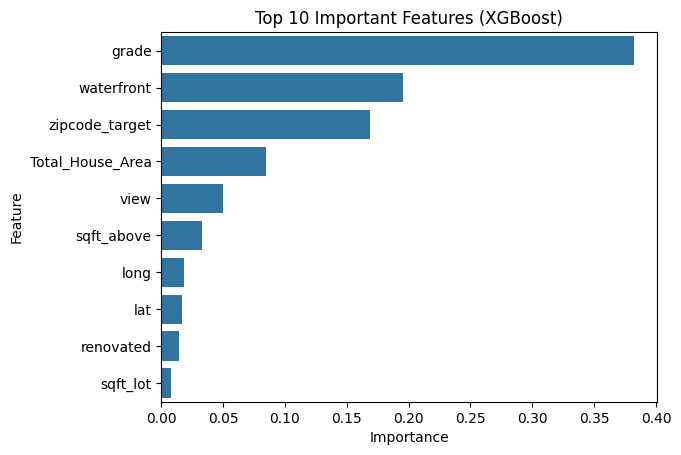

Axes(0.125,0.11;0.775x0.77)


In [ ]:
from xgboost import XGBRegressor

# Step 1: Create model
xgb = XGBRegressor(n_estimators=100, random_state=42)

# Step 2: Train model
xgb.fit(X_train, y_train)

# Step 3: Feature importance
importances = xgb.feature_importances_
features = X.columns

import pandas as pd

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

lr = sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features (XGBoost)")
plt.show()

print(lr)

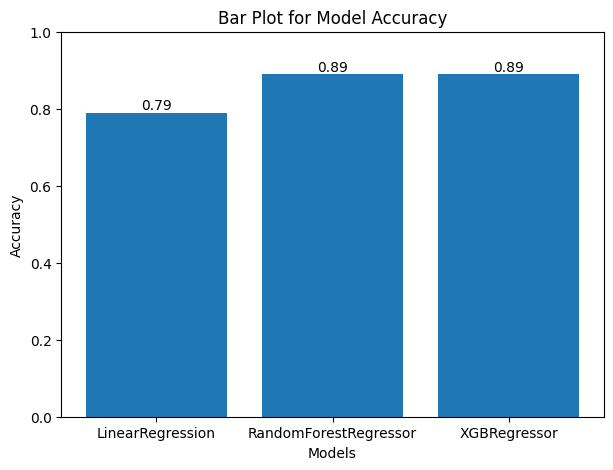

In [ ]:
import matplotlib.pyplot as plt

# Model names and accuracy values
models = [ 'LinearRegression','RandomForestRegressor','XGBRegressor']
accuracies = [0.79, 0.89,0.89]

# Create bar plot
plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Bar Plot for Model Accuracy')
plt.ylim(0, 1)

# Display accuracy values on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc, f'{acc:.2f}', ha='center', va='bottom')

plt.show()

# Conclusion

In this project, I implemented two regression models — Linear Regression and Random Forest — to predict house prices. Linear Regression provided a good baseline but struggled to capture complex, non-linear relationships in the data. Random Forest, on the other hand, performed significantly better due to its ability to model non-linear patterns and interactions between features. Based on evaluation metrics such as RMSE and R² score, Random Forest achieved the highest accuracy and was selected as the final model.”


# Business Impact

The Random Forest model can help real estate businesses, buyers, and sellers estimate accurate house prices based on property features. This enables better pricing decisions, reduces the risk of underpricing or overpricing, and supports data-driven decision-making.